In [1]:
import os
import random
import shutil
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter
from ultralytics import YOLO

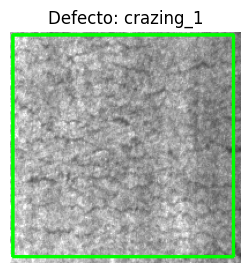

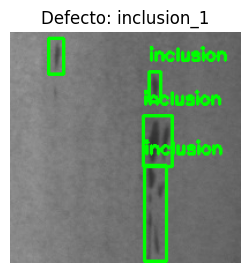

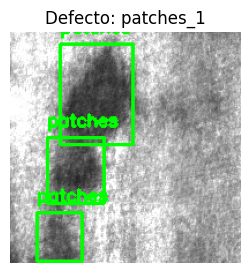

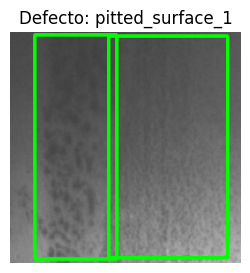

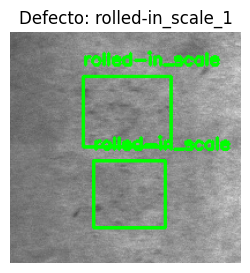

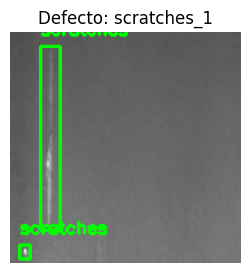

In [2]:
# Rutas (usamos r"" para evitar líos con las barras de Windows)
img_dir = r"../data/raw/IMAGES"
ann_dir = r"../data/raw/ANNOTATIONS"

def plot_defect(img_name):
    # 1. Cargar imagen
    img_path = os.path.join(img_dir, img_name + ".jpg")
    img = cv2.imread(img_path)
    
    # 2. Leer XML (Anotaciones)
    xml_path = os.path.join(ann_dir, img_name + ".xml")
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # 3. Dibujar cada caja de defecto encontrada
    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        
        # Dibujar rectángulo (Verde, grosor 2)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        cv2.putText(img, label, (xmin, ymin-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Defecto: {img_name}")
    plt.axis('off')
    plt.show()

# Probamos con uno de cada (puedes cambiar los nombres)
ejemplos = ["crazing_1", "inclusion_1", "patches_1", "pitted_surface_1", "rolled-in_scale_1", "scratches_1"]
for ej in ejemplos:
    try:
        plot_defect(ej)
    except:
        print(f"No se pudo cargar {ej}, verifica el nombre exacto del archivo.")

In [3]:
# 1. Configuración de rutas
raw_img_dir = Path(r"../data/raw/IMAGES")
raw_ann_dir = Path(r"../data/raw/ANNOTATIONS")
base_data_dir = Path(r"../data")

# 2. Crear carpetas de destino (Añadimos 'test')
for split in ['train', 'val', 'test']:
    (base_data_dir / split / 'images').mkdir(parents=True, exist_ok=True)
    (base_data_dir / split / 'annotations').mkdir(parents=True, exist_ok=True)

# 3. Obtener lista de archivos y mezclar
all_images = [f.stem for f in raw_img_dir.glob("*.jpg")]
random.seed(42) 
random.shuffle(all_images)

# 4. Calcular los puntos de corte para 80% - 10% - 10%
total = len(all_images)
train_end = int(total * 0.80)            # Fin del 80%
val_end = train_end + int(total * 0.10)  # Fin del siguiente 10%

train_list = all_images[:train_end]      # 0% al 80%
val_list = all_images[train_end:val_end] # 80% al 90%
test_list = all_images[val_end:]         # 90% al 100%

def copy_files(file_list, target_split):
    count = 0
    for name in file_list:
        # Rutas de origen
        src_img = raw_img_dir / f"{name}.jpg"
        src_ann = raw_ann_dir / f"{name}.xml"
        
        # Rutas de destino
        dst_img = base_data_dir / target_split / 'images' / f"{name}.jpg"
        dst_ann = base_data_dir / target_split / 'annotations' / f"{name}.xml"
        
        # Copiar archivos
        if src_img.exists() and src_ann.exists():
            shutil.copy(src_img, dst_img)
            shutil.copy(src_ann, dst_ann)
            count += 1
    return count

# 5. Ejecutar el movimiento
print(f"Iniciando copia de archivos (80/10/10)...")
train_count = copy_files(train_list, 'train')
val_count = copy_files(val_list, 'val')
test_count = copy_files(test_list, 'test')

print(f"\n--- PROCESO FINALIZADO ---")
print(f"📦 Imágenes en TRAIN: {train_count} (80%)")
print(f"🧪 Imágenes en VAL:   {val_count} (10%)")
print(f"🔒 Imágenes en TEST:  {test_count} (10%)")
print(f"Total procesado: {train_count + val_count + test_count}")

Iniciando copia de archivos (80/10/10)...

--- PROCESO FINALIZADO ---
📦 Imágenes en TRAIN: 1440 (80%)
🧪 Imágenes en VAL:   180 (10%)
🔒 Imágenes en TEST:  180 (10%)
Total procesado: 1800


In [4]:
classes = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]

In [5]:
def convert_box(size, box):
    # size: (width, height), box: (xmin, xmax, ymin, ymax)
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    # Normalizamos multiplicando por el inverso del tamaño
    return (x * dw, y * dh, w * dw, h * dh)

def process_labels(split_name):
    ann_path = Path(f"../data/{split_name}/annotations")
    labels_path = Path(f"../data/{split_name}/labels") # Carpeta nueva para YOLO
    labels_path.mkdir(parents=True, exist_ok=True)
    
    count = 0
    for xml_file in ann_path.glob("*.xml"):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Obtener dimensiones de la imagen
        size = root.find('size')
        w = int(size.find('width').text)
        h = int(size.find('height').text)
        
        # Crear archivo .txt con el mismo nombre
        txt_file = labels_path / (xml_file.stem + ".txt")
        
        with open(txt_file, 'w') as f:
            for obj in root.findall('object'):
                cls_name = obj.find('name').text
                if cls_name not in classes: continue
                cls_id = classes.index(cls_name)
                
                xmlbox = obj.find('bndbox')
                b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text), 
                     float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
                
                # Convertir a formato YOLO (clase x_center y_center width height)
                bb = convert_box((w, h), b)
                f.write(f"{cls_id} {' '.join([f'{a:.6f}' for a in bb])}\n")
        count += 1
    return count

# Ejecutar para ambos splits
print("Convirtiendo XML a TXT (formato YOLO)...")
train_txt = process_labels('train')
val_txt = process_labels('val')
test_txt = process_labels('test')
print(f"Hecho. Creados {train_txt} archivos en train, {val_txt} en val y {test_txt} en test.")

Convirtiendo XML a TXT (formato YOLO)...
Hecho. Creados 1440 archivos en train, 180 en val y 180 en test.


In [6]:
from ultralytics import YOLO

# 1. Cargamos el modelo YOLOv8 pequeño (yolov8n.pt) 
# Es rápido y perfecto para empezar con el dataset NEU
model = YOLO('yolov8n.pt') 

# 2. Entrenamos el modelo
results = model.train(
    data='../dataset_config.yaml',  # El nuevo nombre que le hemos dado
    epochs=100,
    imgsz=448,
    batch=16,
    mixup=0.5,    # Un toque de MixUp suele ayudar más en acero

    hsv_h=0.015,   # Cambia el tono (color) un poco
    hsv_s=0.7,     # Cambia la saturación
    hsv_v=0.4,     # Cambia el brillo (muy útil para reflejos en el acero)
    degrees=10.0,  # Rota las imágenes hasta 10 grados (recalcula etiquetas solo)
    translate=0.1, # Mueve la imagen un 10% (mueve etiquetas también)
    scale=0.5,     # Zoom hacia afuera/adentro
    flipud=0.5,    # Volteo vertical (50% de probabilidad)
    fliplr=0.5,    # Volteo horizontal (50% de probabilidad)
    mosaic=1.0,    # Mezcla 4 imágenes en una (ya lo hacía, pero aquí lo confirmas)

    name='tfm_steel_aimgsz_448_mixup_0-5',
    device=0
)

New https://pypi.org/project/ultralytics/8.4.26 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=../dataset_config.yaml, epochs=100, time=None, patience=50, batch=16, imgsz=448, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=tfm_steel_aimgsz_448_mixup_0-52, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, em

train: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\train\labels.cache... 1440 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1440/1440 [00:00<?, ?it/s]

train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\crazing_120.jpg: 1 duplicate labels removed
train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\inclusion_62.jpg: 1 duplicate labels removed
train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\patches_198.jpg: 1 duplicate labels removed



val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\val\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]


Plotting labels to runs\detect\tfm_steel_aimgsz_448_mixup_0-52\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/100      1.22G      1.239      1.146      1.451         35        448: 100%|██████████| 90/90 [00:09<00:00,  9.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:00<00:00,  7.03it/s]

                   all        180        396      0.656      0.703      0.724      0.416



100 epochs completed in 0.319 hours.
Optimizer stripped from runs\detect\tfm_steel_aimgsz_448_mixup_0-52\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\tfm_steel_aimgsz_448_mixup_0-52\weights\best.pt, 6.2MB

Validating runs\detect\tfm_steel_aimgsz_448_mixup_0-52\weights\best.pt...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 3006818 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  4.26it/s]


                   all        180        396      0.649      0.722      0.735      0.425
               crazing        180         66      0.586      0.301      0.393      0.152
             inclusion        180        106      0.567      0.821      0.732      0.426
               patches        180         69      0.796      0.942      0.952       0.63
        pitted_surface        180         43      0.747      0.837      0.872      0.508
       rolled-in_scale        180         57      0.506      0.485      0.523      0.258
             scratches        180         55      0.694      0.948      0.939      0.575
Speed: 0.2ms preprocess, 1.1ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs\detect\tfm_steel_aimgsz_448_mixup_0-52


In [7]:
# Evaluar el modelo con las fotos de Test
metrics = model.val(split='test') 
print(f"mAP50 final en TEST: {metrics.box.map50}")

Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 3006818 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<00:00, 737.25it/s]

val: New cache created: C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:03<00:00,  3.96it/s]


                   all        180        442      0.691      0.685      0.729      0.403
               crazing        180         74      0.507      0.257      0.428      0.175
             inclusion        180        113      0.636      0.726      0.721      0.382
               patches        180         80      0.777      0.925      0.927      0.587
        pitted_surface        180         33      0.847      0.697      0.783      0.496
       rolled-in_scale        180         75      0.566       0.61      0.587      0.276
             scratches        180         67      0.814      0.896      0.928      0.504
Speed: 0.3ms preprocess, 9.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs\detect\tfm_steel_aimgsz_448_mixup_0-522
mAP50 final en TEST: 0.7290483913000757



image 1/1 c:\Users\Usuario\Desktop\TFM_NEU\notebooks\..\data\test\images\pitted_surface_64.jpg: 224x224 1 pitted_surface, 11.0ms
Speed: 21.0ms preprocess, 11.0ms inference, 53.0ms postprocess per image at shape (1, 3, 224, 224)

--- ANÁLISIS DE IMAGEN: pitted_surface_64.jpg ---
🤖 IA ha detectado 1 etiquetas:
   [1] pitted_surface (Conf: 0.92) -> Coords: [xmin:0, ymin:0, xmax:199, ymax:198]

📄 ORIGINAL (txt) tiene etiquetas registradas:
   [1] Clase: pitted_surface (ID: 3) -> Coords: [xmin:0, ymin:1, xmax:200, ymax:198]


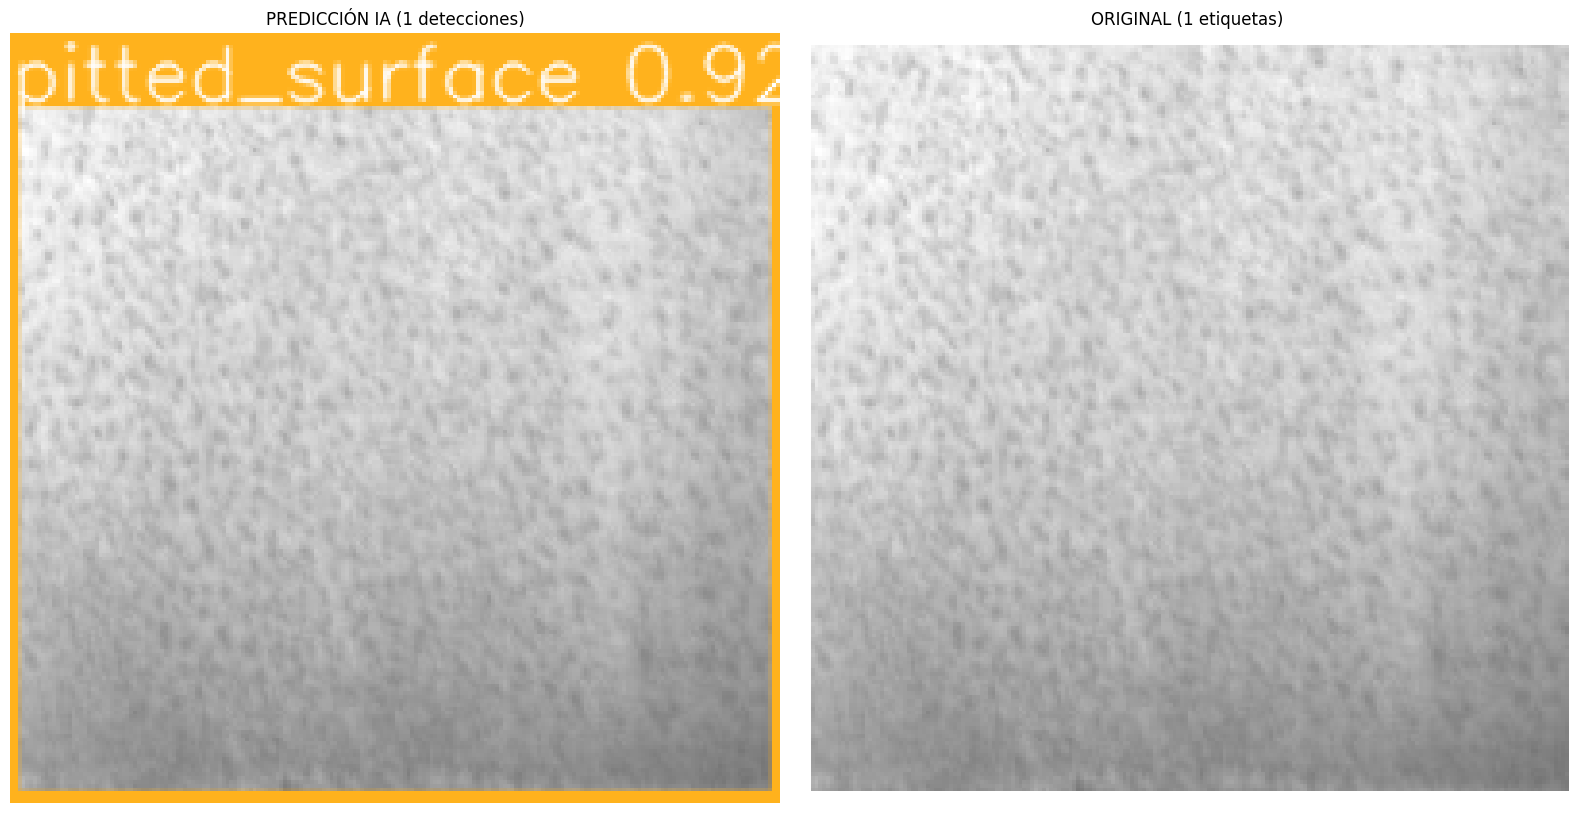

In [8]:
# 1. Configuración de rutas
model_path = r'runs/detect/tfm_steel_v118/weights/best.pt'
model = YOLO(model_path)
test_images_dir = Path('../data/test/images')
test_labels_dir = Path('../data/test/labels')

# 2. Selección aleatoria de imagen y su etiqueta .txt
img_path = random.choice(list(test_images_dir.glob('*.jpg')))
label_path = test_labels_dir / f"{img_path.stem}.txt"

class_names = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

# 3. PREDICCIÓN IA (Izquierda)
results = model(str(img_path))[0]
img_ia = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)

print(f"\n--- ANÁLISIS DE IMAGEN: {img_path.name} ---")
print(f"🤖 IA ha detectado {len(results.boxes)} etiquetas:")
for i, box in enumerate(results.boxes):
    coords = box.xyxy[0].tolist()
    conf = box.conf[0]
    cls = int(box.cls[0])
    name = model.names[cls]
    print(f"   [{i+1}] {name} (Conf: {conf:.2f}) -> Coords: [xmin:{int(coords[0])}, ymin:{int(coords[1])}, xmax:{int(coords[2])}, ymax:{int(coords[3])}]")

# 4. ORIGINAL DESDE TXT (Derecha)
img_original = cv2.imread(str(img_path))
h, w, _ = img_original.shape
original_count = 0

print(f"\n📄 ORIGINAL (txt) tiene etiquetas registradas:")
if label_path.exists():
    with open(label_path, 'r') as f:
        lines = f.readlines()
        original_count = len(lines)
        for i, line in enumerate(lines):
            parts = line.split()
            cls_id = int(parts[0])
            cls, x_c, y_c, wb, hb = map(float, line.split())

            try:
                real_name = class_names[cls_id]
            except IndexError:
                real_name = f"ID Desconocido: {cls_id}"
            # Conversión de normalizado YOLO a píxeles reales
            x1, y1 = int((x_c - wb/2) * w), int((y_c - hb/2) * h)
            x2, y2 = int((x_c + wb/2) * w), int((y_c + hb/2) * h)
            
            # Dibujar en la imagen
            cv2.rectangle(img_original, (x1, y1), (x2, y2), (255, 255, 255), 2)
            cv2.putText(img_original, f"Org:{int(cls)}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
            print(f"   [{i+1}] Clase: {real_name} (ID: {cls_id}) -> Coords: [xmin:{x1}, ymin:{y1}, xmax:{x2}, ymax:{y2}]")
else:
    print("   ⚠️ No se encontró archivo de etiquetas original.")

img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# 5. Visualización Comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.imshow(img_ia)
ax1.set_title(f"PREDICCIÓN IA ({len(results.boxes)} detecciones)")
ax1.axis('off')

ax2.imshow(img_original)
ax2.set_title(f"ORIGINAL ({original_count} etiquetas)")
ax2.axis('off')

plt.tight_layout()
plt.show()